# HMB and MP Phenotype derivation on UK Biobank RAP
Notebook for deriving Heavy Menstrual Bleeding and Menstrual Pain phenotypes for use in a Genome Wide Association Study (GWAS) on the UK Biobank RAP platform.        
*Cell outputs removed in compliance with Biobank data protection rules*

Author: **Adam El Kholy**    
Project P.I: **Dr. Gemma Sharp**    
Department of Psychology in collaboration with the Exeter Genetics Group,           
University of Exeter    
Last updated: 08/01/2025

In [1]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from cluster_ukbython import ukbython
ukb = ukbython()

Running on database app103356_20241205153134...


Record-Table lookup
```R
death_cause_tbl      # ICD10
hesin_diag_tbl       # ICD10, ICD9
cancer_registry_tbl  # ICD10
gp_clinical_tbl      # Read2 / CTV3
hesin_oper_tbl       # OPCS3 / OPCS4
selfrep_illness_tbl  # ukb_cancer / ukb_noncancer
```

HMB Phenotype from Luke's code      
- ICD9: 2063 entries, First date in 1592    
- ICD10: 18990 entries, first date in 14715        
- Read2: 7570 entries, first diagnosis in 4185       

# Heavy Menstrual Bleeding (HMB) phenotype

## ICD9, ICD10 and Read2 codes

Getting ICD9 eids and dates

In [2]:
icd9s = [
    6262,  # excessive or frequent menstruation
    6270   # premenopausal menorrhagia
]
hmb_icd9 = ukb.get_icd9(icd9s)
hmb_icd9_dates = ukb.get_hesin_dates(hmb_icd9, "icd9")

Getting ICD10 eids and dates

In [3]:
icd10s = [
    "N92.0",  # excessive and frequent menstruation with regular cycle
    "N92.1",  # excessive and frequent menstruation with irregular cycle
    "N92.2",  # excessive menstruation at puberty
    "N92.4"   # excessive bleeding in the premenopausal period
]
hmb_icd10_hesin = ukb.get_icd10_hesin(icd10s)
hmb_icd10_hesin_dates = ukb.get_hesin_dates(hmb_icd10_hesin, "icd10")

Get GP clinical eids (Read2/Read3 codes) and dates

In [4]:
Read2 = [
    "K5A0.11",  # climacteric menorrhagia
    "K592.00",  # excessive or frequent menstruation
    "K592z00",  # excessive or frequent menstruation nos
    "1573.11",  # h/o: heavy period
    "573.00",   # h/o: menorrhagia
    "K592012",  # heavy menstrual bleeding
    "K592011",  # heavy periods
    "K592000",  # menorrhagia
    "K5A6.00",  # perimenopausal menorrhagia
    "K5A0.00",  # premenopausal menorrhagia
    "K593.11",  # pubertal bleeding and menorrhagia
    "K592.12",  # hypermenorrhoea
    "K591000"   # hypomenorrhoea
]  

In [5]:
hmb_gp_clinical = ukb.get_gp_clinical(Read2)
hmb_gp_clinical_dates = ukb.get_gp_clinical_dates(hmb_gp_clinical)

Checking ICD10 death records: no entries

In [6]:
# hmb_icd10_death = ukb.get_icd10_death(icd10s)
# hmb_icd10_death.count()

## Tranexamic acid phenotype

Treatment/medication code: field code: 20003  
Tranexamic acid n=699    
code: 1140861832

p20003_i{i}_a{a}
for  
0 to 3 inclusive instances, 
0 to 47 inclusive arrays with 
NO DATES

In [7]:
# all fields potentially containing a treatment code
columns = [f"p20003_i{i}_a{a}" for i in range(4) for a in range(48)]

# extract eids with treatment code for tranexamic acid
query = f"SELECT DISTINCT eid FROM `{ukb.database}`.`participant_0032` WHERE {' OR '.join([f'{col} = 1140861832' for col in columns])}"

tranex_df = ukb.spark.sql(query)

## Endometrial ablation phenotype

Endometrial ablation field code = 20004   
operations code = 1360

In [8]:
# all fields potentially containing an operations code
columns = [f"p20004_i{i}_a{a}" for i in range(4) for a in range(32)]

# put fields into SQL query
case_statements = [f"WHEN {col} = 1360 THEN '{col[8]},{col[11:]}'" for col in columns]
case_condition = " ".join(case_statements)

# extract instance, array index field for date querying
query = f"""
SELECT eid, 
       CASE {case_condition} 
       ELSE NULL 
       END AS idx
FROM `{ukb.database}`.`participant_0032`
WHERE { " OR ".join([f"{col} = 1360" for col in columns]) }
"""

endo_df = ukb.spark.sql(query)

Extracting fields for date of first diagnosis calculation:
- p20010: date of diagnosis
- p20011: age of diagnosis  

Extracting instance and array fields (4 instances with 32 arrays each):
- p20010 fields i0_a0 to i0_a9 are in p_0033, the rest are in p_0034
- p20011 fields are all in p_0034

In [9]:
# field names for querying p0033 and p0034, defined as above
p_33_selections = ["eid"] + [f"p20010_i0_a{a}" for a in range(10)]
p_34_selections = ["eid"] + [f"p20010_i{i}_a{a}" for i in range(4) for a in range(32) if int(i) != 0 or int(a) > 9] + [f"p20011_i{i}_a{a}" for i in range(4) for a in range(32)]

# querying p0033, p0034, and date of birth register
p_33_df = ukb.spark.sql(f"SELECT eid, {', '.join(p_33_selections)} FROM `{ukb.database}`.`participant_0033`")
p_34_df = ukb.spark.sql(f"SELECT eid, {', '.join(p_34_selections)} FROM `{ukb.database}`.`participant_0034`")
dob_df = ukb.spark.sql(f"SELECT eid, p34 FROM  `{ukb.database}`.`participant_0001`")

# inner joins to create master dataframe
main_df = endo_df.join(p_33_df, on="eid", how="inner")
main_df = main_df.join(p_34_df, on="eid", how="inner")
main_df = main_df.join(dob_df, on="eid", how="inner")

In [10]:
# convert spark DataFrame into Python list
endo_list = main_df.collect()

In [11]:
endo_ages_list = []

# enumerate endometrial ablation eids
for entry in endo_list:
    # extract instance, array indexes
    i, a = entry["idx"].split(",")

    # get date of birth
    dob = entry["p34"]

    # get age and date of diagnosis
    age = entry[f"p20011_i{i}_a{a}"]
    date = entry[f"p20010_i{i}_a{a}"]

    # convert date to age
    date_to_age = round(date - dob, 1)

    # validation for calculating correct min value
    if age <= 0:
        age = 10000
    if date_to_age <= 0:
        date_to_age = 10000
    first_diagnosis_age = min(age, date_to_age)

    if first_diagnosis_age == 10000:
        first_diagnosis_age = None

    endo_ages_list.append([int(entry["eid"]), first_diagnosis_age])

# print("\n".join([str(e) for e in endo_ages_list[:10]]))
# print(len(endo_ages_list))


In [12]:
endo_ages_df = ukb.spark.createDataFrame(endo_ages_list, schema=['eid', 'first_diagnosis_age'])

## Final HMB phenotype

Derived variables:   
• hmb_ever <- any diagnosis ever recorded vs no diagnosis ever recorded    
• hmb_incident_ado <- any diagnosis before or equal to age 19 vs no diagnosis before or equal to age 19    
• hmb_incident_mid <- any diagnosis between age 20-44 (inclusive) vs no diagnosis between age 20-44 (inclusive)    
• hmb_incident_meno <- any diagnosis between age 45-60 (inclusive) vs no diagnosis between age 45-60 (inclusive)    

In [13]:
# join all dates entries into one table
all_dates_df = hmb_icd9_dates.join(hmb_icd10_hesin_dates, on="eid", how="outer")
all_dates_df = all_dates_df.join(hmb_gp_clinical_dates, on="eid", how="outer")

In [14]:
# get the earliest date across all fields
first_date_df = all_dates_df.withColumn('first_diagnosis_date', F.least(F.col('icd9_first_diagnosis_date'), F.col('icd10_first_diagnosis_date'), F.col('gp_first_diagnosis_date')))
first_date_df = first_date_df.select("eid", "first_diagnosis_date")

In [15]:
# join dobs with first diagnosis dates
dates_to_ages_df = first_date_df.join(dob_df, on="eid", how="inner")

# subtract date of birth from diagnosis date to get age at diagnosis
dates_to_ages_df = dates_to_ages_df.withColumn(
    "first_diagnosis_age_unfiltered", 
    dates_to_ages_df["first_diagnosis_date"] - dates_to_ages_df["p34"]
)

# replace ages <= 0 with null in a column 
dates_to_ages_df = dates_to_ages_df.withColumn(
    'first_diagnosis_age_',
    F.when(F.col('first_diagnosis_age_unfiltered') <= 0, F.lit(None))  # if value <= 0, set it to null
    .otherwise(F.col('first_diagnosis_age_unfiltered'))                # otherwise keep the original value
)

all_ages_df = dates_to_ages_df.select("eid", "first_diagnosis_age_")

In [16]:
# finally get mininum age of diagnosis from [min(ICD9, ICD10, Read2 codes)] , [endometrial ablation]
combined_ages_df = all_ages_df.join(endo_ages_df, on="eid", how="outer")
final_ages_df = combined_ages_df.withColumn('diagnosis_age', F.least(F.col('first_diagnosis_age_'), F.col('first_diagnosis_age')))
final_ages_df = final_ages_df.select("eid", "diagnosis_age")

In [17]:
# finally join tranxamic acid participants (for whom no dates str available)
hmb_phenotype_df = final_ages_df.join(tranex_df, on="eid", how="outer")

## Filtering female participants only

In [18]:
query = f"SELECT DISTINCT eid FROM `{ukb.database}`.`participant_0001` WHERE p31 == 0"
females_df = ukb.spark.sql(query)
hmb_phenotype_df = females_df.join(hmb_phenotype_df, on="eid", how="inner")

## Deriving HMB variables
• hmb_ever <- any diagnosis ever recorded vs no diagnosis ever recorded    
• hmb_incident_ado <- any diagnosis before or equal to age 19 vs no diagnosis before or equal to age 19    
• hmb_incident_mid2 <- with a different age at first diagnosis range: 20 <= age <= 40          
• hmb_incident_meno2 <- with a different age at first diagnosis range: age >= 40    
• filter out over 60s

In [86]:
def derive_variables(df, name):
    # code variables (1 for yes, 0 for no)
    phenotype_df = df.withColumn(
        "diagnosis_age",
        F.when(F.col("diagnosis_age") < 0, None).otherwise(F.col("diagnosis_age")),
    )
    phenotype_df = phenotype_df.withColumn(
        f"{name}_incident_ado",
        F.when(
            (F.col("diagnosis_age") > 0) & (F.col("diagnosis_age") <= 19), F.lit(1)
        ).otherwise(F.lit(0)),
    )
    phenotype_df = phenotype_df.withColumn(
        f"{name}_incident_mid2",
        F.when(
            (F.col("diagnosis_age") > 19) & (F.col("diagnosis_age") <= 40), F.lit(1)
        ).otherwise(F.lit(0)),
    )
    phenotype_df = phenotype_df.withColumn(
        f"{name}_incident_meno2",
        F.when(F.col("diagnosis_age") > 40, F.lit(1)).otherwise(F.lit(0)),
    )
    phenotype_df = phenotype_df.withColumn(
        f"{name}_over60",
        F.when(F.col("diagnosis_age") > 60, F.lit(1)).otherwise(F.lit(0)),
    )
    # ever variable: filter out over 60s
    phenotype_df = phenotype_df.withColumn(
        f"{name}_ever",
        F.when(F.col(f"{name}_over60") == 1, F.lit(0)).otherwise(F.lit(1)),
    )


    # calculate summary statistics
    summary_stats = (
        phenotype_df.agg(
            F.sum(F.col(f"{name}_ever")).alias("n"),
            F.avg(
                F.when((F.col("diagnosis_age").isNotNull()) & (F.col(f"{name}_ever") == 1), F.col("diagnosis_age"))
            ).alias("avg_diagnosis_age"),
            F.sum(
                F.when(F.col("diagnosis_age").isNull(), 1).otherwise(0)
            ).alias("null_ages"),
            F.sum(F.col(f"{name}_incident_ado")).alias(f"{name}_incident_ado_count"),
            F.sum(F.col(f"{name}_incident_mid2")).alias(f"{name}_incident_mid_count2"),
            F.sum(F.col(f"{name}_incident_meno2")).alias(f"{name}_incident_meno_count2"),
            F.sum(F.col(f"{name}_over60")).alias(f"{name}_over60_count"),
        )
        .collect()[0]
        .asDict()
    )

    summary_stats["name"] = name

    return phenotype_df, summary_stats


In [87]:
def print_summary_statistics(counts, n=None):
    if not n:
        n = counts["n"]
    
    name = counts["name"]
    percent = lambda x: (x / n) * 100
    print(f"---------------------------- {name} summary statistics ----------------------------")

    categories = [
        ("age ≤ 19", counts[f"{name}_incident_ado_count"]),
        ("19 < age ≤ 40", counts[f"{name}_incident_mid_count2"]),
        ("40 < age ≤ 60", counts[f"{name}_incident_meno_count2"]),
        # ("age > 60", counts[f"{name}_over60_count"]),  
        ("age unavailable", counts["null_ages"])
    ]

    print(f"{'Age Category':<20} {'Count':<10} {'Percentage':<12}")
    print("-" * 50)
    
    for category, count in categories:
        print(f"{category:<20} {count:<10} {percent(count):.2f}%")
        
    print("--------------------------------------------------------------------------------")
    print(f"{name} diagnoses over 60 (excluded): {counts[f'{name}_over60_count']}")  
    print(f"total women with {name}: {n}")
    print(f"average diagnosis age: {counts['avg_diagnosis_age']:.2f}")


In [88]:
# plot age categorisation pie chart
def plot_counts_pie_chart(counts):
    name = counts["name"]
    percent = lambda x: (x / counts["n"]) * 100

    labels = ["age ≤ 19", "19 < age ≤ 40", "40 < age ≤ 60",  "age unavailable"] # "age > 60",
    frequencies = [
        counts[f'{name}_incident_ado_count'],
        counts[f'{name}_incident_mid_count2'],
        counts[f'{name}_incident_meno_count2'],
        # counts[f'{name}_over60_count'],
        counts['null_ages']
    ]

    colors = ['gold', 'lightblue', 'lightcoral', 'limegreen'] #, 'orange']  

    plt.figure(figsize=(8, 6))
    wedges, texts = plt.pie(
        frequencies,
        labels=None,        
        colors=colors,
        startangle=140,
        wedgeprops={'edgecolor': 'black'}  
    )

    plt.legend(
        labels=[f"{label} ({percent(frequencies):.2f}%)" for label, frequencies in zip(labels, frequencies)],  # n={frequencies}
        title="Age Groups", 
        loc="center left", 
        bbox_to_anchor=(1, 0.5), 
        fontsize=12,              
        title_fontsize=14        
    )

    plt.title(f"Age distribution for {name}", fontsize=18)
    plt.show()

In [89]:
hmb_phenotype_df_, hmb_counts = derive_variables(hmb_phenotype_df, "hmb")

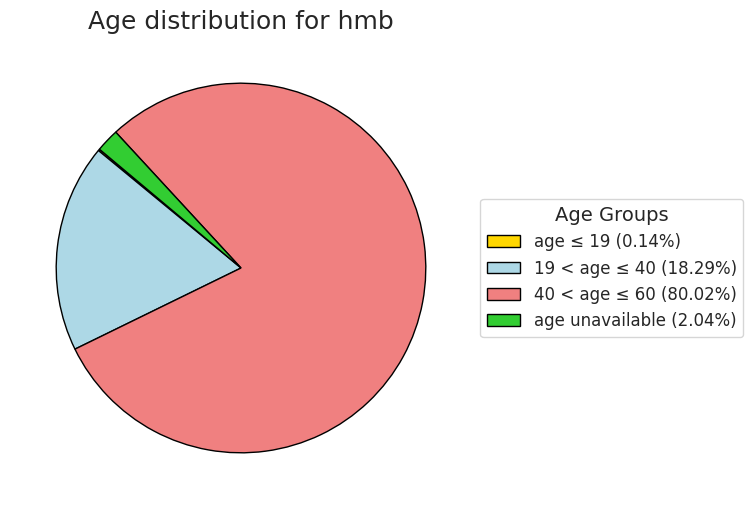

---------------------------- hmb summary statistics ----------------------------
Age Category         Count      Percentage  
--------------------------------------------------
age ≤ 19             31         0.14%
19 < age ≤ 40        3914       18.29%
40 < age ≤ 60        17121      80.02%
age unavailable      437        2.04%
--------------------------------------------------------------------------------
hmb diagnoses over 60 (excluded): 108
total women with hmb: 21395
average diagnosis age: 45.40
% of women with hmb: 7.83%


In [90]:
plot_counts_pie_chart(hmb_counts)
print_summary_statistics(hmb_counts)
print(f"% of women with hmb: {((hmb_counts['n'] / 273157) * 100):.2f}%")

## Control group

Control: Any females with EHR data

In [91]:
# filter female eids from all EHR tables
filter_females = lambda df: females_df.join(df, on="eid", how="inner")
icd9_df = filter_females(ukb.spark.sql(f"SELECT DISTINCT eid FROM `{ukb.database}`.`hesin_diag`"))
gp_df = filter_females(ukb.spark.sql(f"SELECT DISTINCT eid FROM `{ukb.database}`.`gp_clinical`"))
death_df = filter_females(ukb.spark.sql(f"SELECT DISTINCT eid FROM `{ukb.database}`.`death_cause`"))
opcs_df = filter_females(ukb.spark.sql(f"SELECT DISTINCT eid FROM `{ukb.database}`.`hesin_oper`"))
cancer_df = filter_females(ukb.spark.sql(f"SELECT DISTINCT eid FROM `{ukb.database}`.`participant_0073`"))

In [92]:
# join to make control DF
control_df = icd9_df.join(gp_df, on="eid", how="outer")
control_df = control_df.join(death_df, on="eid", how="outer")
control_df = control_df.join(opcs_df, on="eid", how="outer")
control_df = control_df.join(cancer_df, on="eid", how="outer")

## HMB phenotype with control

In [95]:
hmb_final_df = control_df.join(hmb_phenotype_df_, on="eid", how="outer")
hmb_final_df = hmb_final_df.withColumn("hmb_ever", F.when(F.col("hmb_ever").isNull(), F.lit(0)).otherwise(F.col("hmb_ever")))
hmb_final_df = hmb_final_df.withColumnRenamed("diagnosis_age", "hmb_diagnosis_age")
hmb_final_df = hmb_final_df.select(*["eid", "hmb_ever", "hmb_diagnosis_age", "hmb_incident_ado", "hmb_incident_mid2", "hmb_incident_meno2", "hmb_over60"])
hmb_final_df.count()

273157

In [ ]:
# hmb_final_df.show()

# Menstrual Pain (MP) phenotype

## Self-report questionnaire

- p21050 found in participant_0042             
- p21026 found in participant_0042        
   

Self-report questionnaire (available for MP only - not HMB)         
• 21050: During the past 3 months, how much have you been bothered by menstrual cramps or other problems with your periods? [n bothered a lot =1083]            
-600	Not bothered at all       
-601	Bothered a little       
-602	Bothered a lot         
-818	Prefer not to answer         
-313	Not applicable         

• 21026: Did this discomfort or pain occur only during your menstrual bleeding and not at other times? [n yes =1121]          
1	Yes    
0	No     
-818	Prefer not to answer     
-313	Not applicable         

Participants answering “bothered a lot” to 21050 and “yes” to 21026 should be coded as a case!          

In [25]:
# menstrual pain self report variable
query = f"SELECT eid, p21050, p21026 FROM `{ukb.database}`.`participant_0042` WHERE p21050 == -602 AND p21026 == 1"
mp_selfrep_df = ukb.spark.sql(query)
mp_selfrep_df = mp_selfrep_df.select("eid")

## Mefenamic acid

Mefenamic acid code = 1140871542

In [26]:
# all fields potentially containing a treatment code
columns = [f"p20003_i{i}_a{a}" for i in range(4) for a in range(48)]

# extract eids with treatment code for mefenamic acid
query = f"SELECT DISTINCT eid FROM `{ukb.database}`.`participant_0032` WHERE {' OR '.join([f'{col} = 1140871542' for col in columns])}"

mefenamic_df = ukb.spark.sql(query)

## ICD0, ICD10 and Read2 Codes

In [27]:
icd9 = [6253]  # dysmenorrhoea
mp_icd9 = ukb.get_icd9(icd9)
mp_icd9_dates = ukb.get_hesin_dates(mp_icd9, "icd9")

In [28]:
ICD10 = [
    "N94.4",  # primary dysmenorrhoea
    "N94.5",  # secondary dysmenorrhoea
    "N94.6"   # dysmenorrhoea, unspecified
]
mp_icd10_hesin = ukb.get_icd10_hesin(ICD10)
mp_icd10_hesin_dates = ukb.get_hesin_dates(mp_icd10_hesin, "icd10")

In [29]:
Read2 = [
    "Eu45y11",  # psychogenic dysmenorrhoea
    "K583.00",  # dysmenorrhoea
    "1574.00",  # h/o: dysmenorrhoea
    "1574.11",  # h/o: painful periods
    "K583.11",  # painful menorrhoea
    "K583.12",  # painful menstruation
    "K583.13",  # period pains
    "K583000",  # primary dysmenorrhoea
    "E265200",  # psychogenic dysmenorrhea
    "K583100",  # secondary dysmenorrhoea
    "K583.14"   # spasmodic dysmenorrhoea
]


In [30]:
mp_gp_clinical = ukb.get_gp_clinical(Read2)
mp_gp_clinical_dates = ukb.get_gp_clinical_dates(mp_gp_clinical)

## Final MP phenotype

In [31]:
# join all dates entries into one table
all_dates_df = mp_icd9_dates.join(mp_icd10_hesin_dates, on="eid", how="outer")
all_dates_df = all_dates_df.join(mp_gp_clinical_dates, on="eid", how="outer")

In [32]:
# get the earliest date across all fields
first_date_df = all_dates_df.withColumn('first_diagnosis_date', F.least(F.col('icd9_first_diagnosis_date'), F.col('icd10_first_diagnosis_date'), F.col('gp_first_diagnosis_date')))
first_date_df = first_date_df.select("eid", "first_diagnosis_date")

In [33]:
# join dobs with first diagnosis dates
dates_to_ages_df = first_date_df.join(dob_df, on="eid", how="inner")

# subtract date of birth from diagnosis date to get age at diagnosis
dates_to_ages_df = dates_to_ages_df.withColumn(
    "first_diagnosis_age_unfiltered", 
    dates_to_ages_df["first_diagnosis_date"] - dates_to_ages_df["p34"]
)

# replace ages <= 0 with null in a column 
dates_to_ages_df = dates_to_ages_df.withColumn(
    'diagnosis_age',
    F.when(F.col('first_diagnosis_age_unfiltered') <= 0, F.lit(None))  # if value <= 0, set it to null
    .otherwise(F.col('first_diagnosis_age_unfiltered'))                # otherwise keep the original value
)

all_ages_df = dates_to_ages_df.select("eid", "diagnosis_age")

In [34]:
# finally join mefenamic acid and self reoport participants (for whom no dates available)
mp_phenotype_df = all_ages_df.join(mefenamic_df, on="eid", how="outer")
mp_phenotype_df = mp_phenotype_df.join(mp_selfrep_df, on="eid", how="outer")

## Filtering female participants only

In [35]:
mp_phenotype_df = females_df.join(mp_phenotype_df, on="eid", how="inner")

## Deriving MP variables

Derived variables         
• mp_ever <- any diagnosis ever recorded vs no diagnosis ever recorded        
• mp_incident_ado <- any diagnosis before or equal to age 19 vs no diagnosis before or equal to age 19         
• mp_incident_mid <- any diagnosis between age 20-44 (inclusive) vs no diagnosis between age 20-44 (inclusive)      
• mp_incident_meno <- any diagnosis between age 45-60 (inclusive) vs no diagnosis between age 45-60 (inclusive)      



In [36]:
mp_phenotype_df_, mp_counts = derive_variables(mp_phenotype_df, "mp")

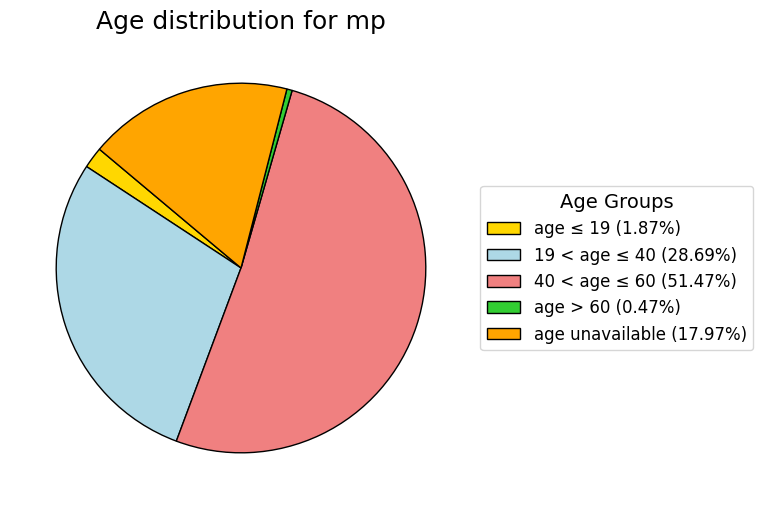

---------------------------- mp summary statistics ----------------------------
Age Category         Count      Percentage  
--------------------------------------------------
age ≤ 19             76         1.87%
19 < age ≤ 40        1164       28.69%
40 < age ≤ 60        2088       51.47%
age > 60             19         0.47%
age unavailable      729        17.97%
--------------------------------------------------------------------------------
total women with mp: 4057
average diagnosis age: 41.57
% of women with hmb: 1.49%


In [37]:
plot_counts_pie_chart(mp_counts)
print_summary_statistics(mp_counts)
print(f"% of women with hmb: {((mp_counts['n'] / 273157) * 100):.2f}%")

## MP phenotype with control group

In [97]:
mp_final_df = control_df.join(mp_phenotype_df_, on="eid", how="outer")
mp_final_df = mp_final_df.withColumn("mp_ever", F.when(F.col("mp_ever").isNull(), F.lit(0)).otherwise(F.col("mp_ever")))
mp_final_df = mp_final_df.withColumnRenamed("diagnosis_age", "mp_diagnosis_age")
mp_final_df = mp_final_df.select(*["eid", "mp_ever", "mp_diagnosis_age", "mp_incident_ado", "mp_incident_mid2", "mp_incident_meno2", "mp_over60"])
mp_final_df.count()

273157

# Final HMB and MP phenotype 

In [ ]:
final_phenotype_df = hmb_final_df.join(mp_final_df, on="eid", how="outer")

# Age distribution curve

In [39]:
import seaborn as sns

# filter out rows where 'diagnosis_age' is null
filtered_ages = (
    mp_phenotype_df.filter(mp_phenotype_df["diagnosis_age"].isNotNull())
    .select("diagnosis_age")
    .rdd.flatMap(lambda x: x)
    .collect()
)

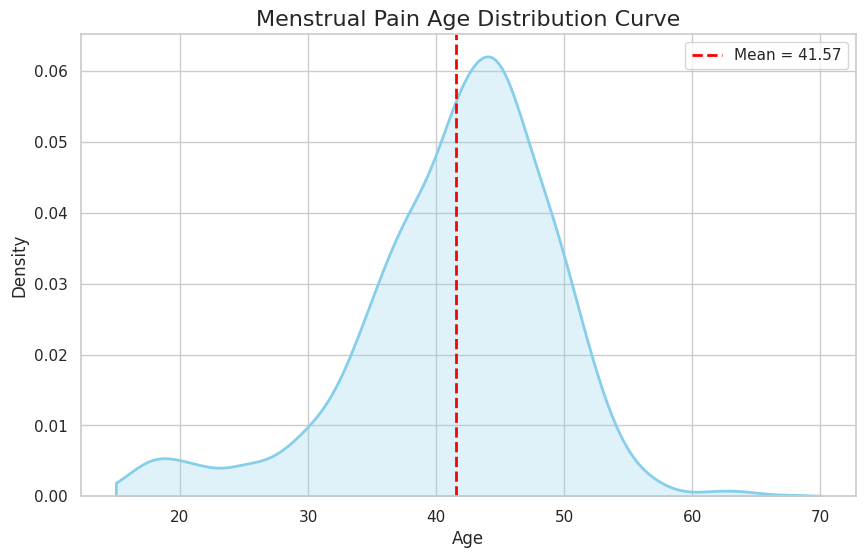

In [40]:
sns.set_theme(style="whitegrid")  
plt.figure(figsize=(10, 6))  

# calculate average diagnosis age and plot age distribution curve
avg_diagnosis_age = mp_counts["avg_diagnosis_age"]

sns.kdeplot(filtered_ages, fill=True, clip=(15, 70), color='skyblue', linewidth=2)
plt.axvline(avg_diagnosis_age, color='red', linestyle='--', linewidth=2, label=f"Mean = {avg_diagnosis_age:.2f}")

plt.title("Menstrual Pain Age Distribution Curve", fontsize=16)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()
plt.show()